In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from implicit.als import AlternatingLeastSquares
from implicit.nearest_neighbours import bm25_weight, tfidf_weight
from scipy.sparse import csr_matrix

%matplotlib inline

In [23]:
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

print("Рейтинги:", ratings.shape)
print("Фильмы:", movies.shape)

Рейтинги: (100836, 4)
Фильмы: (9742, 3)


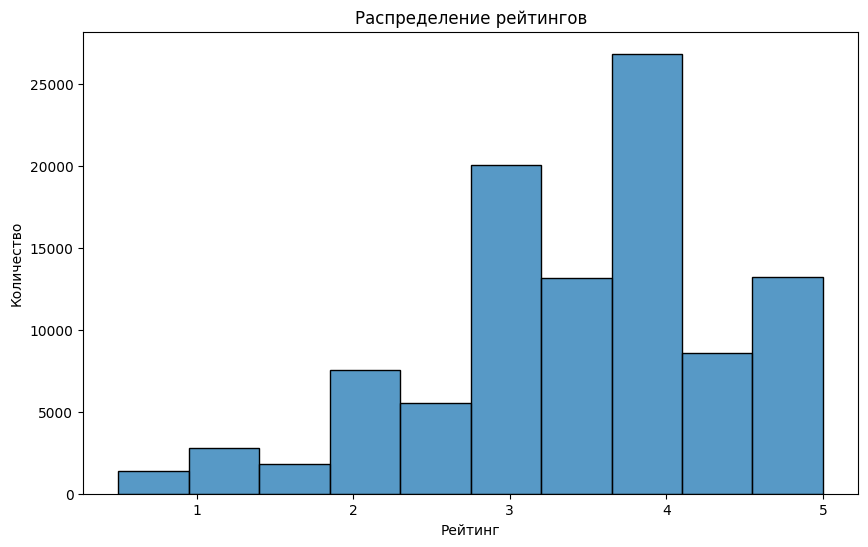

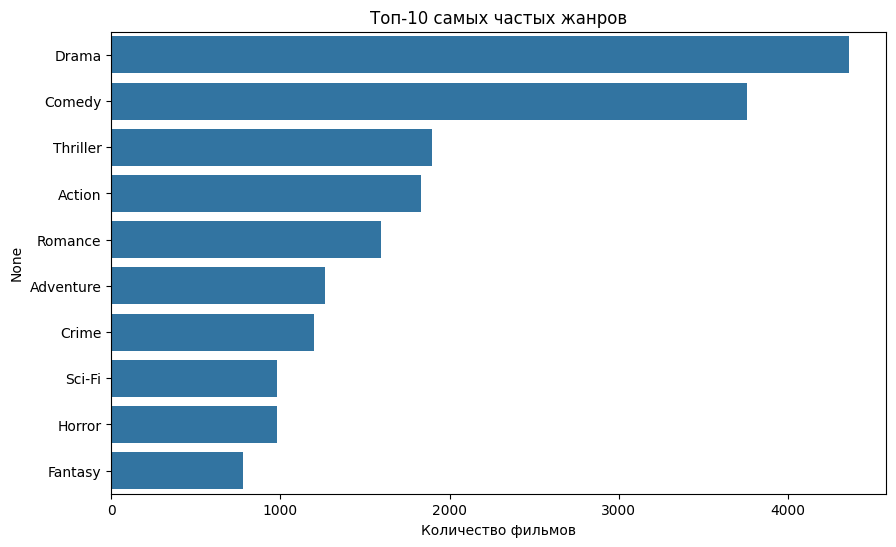

In [24]:
plt.figure(figsize=(10,6))
sns.histplot(ratings['rating'], bins=10)
plt.title('Распределение рейтингов')
plt.xlabel('Рейтинг')
plt.ylabel('Количество')
plt.show()

genre_series = movies['genres'].str.split('|', expand=True).stack()
genre_counts = genre_series.value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title('Топ-10 самых частых жанров')
plt.xlabel('Количество фильмов')
plt.show()

In [25]:
def content_based_recommendations(movie_title, movies_df, top_n=10):
    tfidf = TfidfVectorizer(stop_words='english')
    movies_df['genres'] = movies_df['genres'].fillna('')
    tfidf_matrix = tfidf.fit_transform(movies_df['genres'])
    cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
    
    indices = pd.Series(movies_df.index, index=movies_df['title']).drop_duplicates()
    if movie_title not in indices:
        print(f"Фильм '{movie_title}' не найден.")
        return []
    idx = indices[movie_title]
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    movie_indices = [i[0] for i in sim_scores]
    return movies_df['title'].iloc[movie_indices].tolist()

In [26]:
def collaborative_filtering_recommendations_als(user_id, ratings_df, movies_df, top_n=10):
    user_ids = ratings_df['userId'].unique()
    movie_ids = ratings_df['movieId'].unique()
    user_to_idx = {uid: i for i, uid in enumerate(user_ids)}
    movie_to_idx = {mid: i for i, mid in enumerate(movie_ids)}
    
    rows = ratings_df['userId'].map(user_to_idx).values
    cols = ratings_df['movieId'].map(movie_to_idx).values
    data = ratings_df['rating'].values.astype(np.float32)
    
    user_movie_matrix = csr_matrix((data, (rows, cols)), shape=(len(user_ids), len(movie_ids)))
    
    model = AlternatingLeastSquares(factors=50, regularization=0.01, iterations=15)
    model.fit(user_movie_matrix)
    
    if user_id not in user_to_idx:
        print(f"Пользователь {user_id} не найден.")
        return []
    user_idx = user_to_idx[user_id]
    
    ids, scores = model.recommend(user_idx, user_movie_matrix[user_idx], N=top_n)
    
    movie_indices = ids
    idx_to_movie = {i: mid for mid, i in movie_to_idx.items()}
    movie_ids_rec = [idx_to_movie[i] for i in movie_indices]
    
    return movies_df[movies_df['movieId'].isin(movie_ids_rec)]['title'].tolist()

In [27]:
def hybrid_recommendations(user_id, movie_title, ratings_df, movies_df, top_n=10):
    content_recs = content_based_recommendations(movie_title, movies_df, top_n=top_n)
    collab_recs = collaborative_filtering_recommendations_als(user_id, ratings_df, movies_df, top_n=top_n)
    
    combined = content_recs + collab_recs
    unique_recs = list(dict.fromkeys(combined))
    return unique_recs[:top_n]

In [28]:
user_id_example = 1
movie_title_example = 'Toy Story (1995)'

recommendations = hybrid_recommendations(user_id_example, movie_title_example, ratings, movies, top_n=10)

print(f"Рекомендации для пользователя {user_id_example} на основе фильма '{movie_title_example}':")
for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

  0%|          | 0/15 [00:00<?, ?it/s]

Рекомендации для пользователя 1 на основе фильма 'Toy Story (1995)':
1. Antz (1998)
2. Toy Story 2 (1999)
3. Adventures of Rocky and Bullwinkle, The (2000)
4. Emperor's New Groove, The (2000)
5. Monsters, Inc. (2001)
6. Wild, The (2006)
7. Shrek the Third (2007)
8. Tale of Despereaux, The (2008)
9. Asterix and the Vikings (Astérix et les Vikings) (2006)
10. Turbo (2013)


In [29]:
user_high_ratings = ratings[(ratings['userId'] == 1) & (ratings['rating'] >= 4)]
top_user_movies = movies[movies['movieId'].isin(user_high_ratings['movieId'])]['title'].tolist()
print("Любимые фильмы пользователя 1:")
for i, m in enumerate(top_user_movies[:10], 1):
    print(f"{i}. {m}")

Любимые фильмы пользователя 1:
1. Toy Story (1995)
2. Grumpier Old Men (1995)
3. Heat (1995)
4. Seven (a.k.a. Se7en) (1995)
5. Usual Suspects, The (1995)
6. Bottle Rocket (1996)
7. Braveheart (1995)
8. Rob Roy (1995)
9. Canadian Bacon (1995)
10. Desperado (1995)
